<a href="https://www.kaggle.com/code/ravipoddar26/bank-customer-cunk?scriptVersionId=347897444" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/radheshyamkollipara/bank-customer-churn/Customer-Churn-Records.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/radheshyamkollipara/bank-customer-churn/Customer-Churn-Records.csv')

In [3]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df['Exited'].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [6]:
data = df.drop(columns=['RowNumber','CustomerId','Surname'])

In [7]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [8]:
data['Card Type'].value_counts()

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

In [9]:
data.shape

(10000, 15)

In [10]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [11]:
x = data.drop(columns=['Exited'])
y = data['Exited']

In [12]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [13]:
x.shape

(10000, 14)

In [14]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [15]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [16]:
y.shape

(10000,)

In [17]:
import sklearn

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [20]:
x_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
9254,686,France,Male,32,6,0.00,2,1,1,179093.26,0,2,DIAMOND,510
1561,632,Germany,Male,42,4,119624.60,2,1,1,195978.86,0,4,PLATINUM,959
1670,559,Spain,Male,24,3,114739.92,1,1,0,85891.02,1,4,SILVER,327
6087,561,France,Female,27,9,135637.00,1,1,0,153080.40,1,2,SILVER,567
6669,517,France,Male,56,9,142147.32,1,0,0,39488.04,1,3,PLATINUM,727


In [21]:
x_train.shape


(8000, 14)

In [22]:
x_test.shape

(2000, 14)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

transformer = ColumnTransformer(
    transformers=[
        (
            'ordinal',
            OrdinalEncoder(
                categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']]
            ),
            ['Card Type']
        ),
        (
            'onehot',
            OneHotEncoder(
                sparse_output=False,
                drop='first'
            ),
            ['Geography', 'Gender']
        )
    ],
    remainder='passthrough'
)

In [24]:
x_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
9254,686,France,Male,32,6,0.00,2,1,1,179093.26,0,2,DIAMOND,510
1561,632,Germany,Male,42,4,119624.60,2,1,1,195978.86,0,4,PLATINUM,959
1670,559,Spain,Male,24,3,114739.92,1,1,0,85891.02,1,4,SILVER,327
6087,561,France,Female,27,9,135637.00,1,1,0,153080.40,1,2,SILVER,567
6669,517,France,Male,56,9,142147.32,1,0,0,39488.04,1,3,PLATINUM,727


In [25]:
x_train_trans = transformer.fit_transform(x_train)

In [26]:
x_test_trans = transformer.transform(x_test)

In [27]:
x_train.head(1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Card Type,Point Earned
9254,686,France,Male,32,6,0.0,2,1,1,179093.26,0,2,DIAMOND,510


In [28]:
dat = pd.DataFrame(x_train_trans)
dat

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,3.0,0.0,0.0,1.0,686.0,32.0,6.0,0.00,2.0,1.0,1.0,179093.26,0.0,2.0,510.0
1,2.0,1.0,0.0,1.0,632.0,42.0,4.0,119624.60,2.0,1.0,1.0,195978.86,0.0,4.0,959.0
2,0.0,0.0,1.0,1.0,559.0,24.0,3.0,114739.92,1.0,1.0,0.0,85891.02,1.0,4.0,327.0
3,0.0,0.0,0.0,0.0,561.0,27.0,9.0,135637.00,1.0,1.0,0.0,153080.40,1.0,2.0,567.0
4,2.0,0.0,0.0,1.0,517.0,56.0,9.0,142147.32,1.0,0.0,0.0,39488.04,1.0,3.0,727.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.0,0.0,0.0,1.0,768.0,54.0,8.0,69712.74,1.0,1.0,1.0,69381.05,0.0,3.0,569.0
7996,2.0,0.0,0.0,0.0,682.0,58.0,1.0,0.00,1.0,1.0,1.0,706.50,0.0,4.0,709.0
7997,0.0,0.0,0.0,0.0,735.0,38.0,1.0,0.00,3.0,0.0,0.0,92220.12,1.0,5.0,678.0
7998,3.0,0.0,0.0,1.0,667.0,43.0,8.0,190227.46,1.0,1.0,0.0,97508.04,1.0,3.0,680.0


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_trans)
x_test_scaled = scaler.transform(x_test_trans)

In [30]:
x_train_scaled

array([[ 1.33894677, -0.57946723, -0.57638802, ..., -0.50994211,
        -0.72001005, -0.43019311],
       [ 0.44325531,  1.72572313, -0.57638802, ..., -0.50994211,
         0.70434217,  1.56590792],
       [-1.34812761, -0.57946723,  1.73494238, ...,  1.96100692,
         0.70434217, -1.24374877],
       ...,
       [-1.34812761, -0.57946723, -0.57638802, ...,  1.96100692,
         1.41651828,  0.31667765],
       [ 1.33894677, -0.57946723, -0.57638802, ...,  1.96100692,
        -0.00783394,  0.32556897],
       [ 1.33894677,  1.72572313, -0.57638802, ..., -0.50994211,
         0.70434217,  0.14329694]])

In [31]:
da = pd.DataFrame(x_train_scaled)
da

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.338947,-0.579467,-0.576388,0.913248,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,-0.509942,-0.720010,-0.430193
1,0.443255,1.725723,-0.576388,0.913248,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,-0.509942,0.704342,1.565908
2,-1.348128,-0.579467,1.734942,0.913248,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,1.961007,0.704342,-1.243749
3,-1.348128,-0.579467,-0.576388,-1.094993,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1.961007,-0.720010,-0.176791
4,0.443255,-0.579467,-0.576388,0.913248,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1.961007,-0.007834,0.534515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,-1.348128,-0.579467,-0.576388,0.913248,1.207474,1.435808,1.039728,-0.102301,-0.916688,0.649203,0.974817,-0.539860,-0.509942,-0.007834,-0.167899
7996,0.443255,-0.579467,-0.576388,-1.094993,0.314989,1.816097,-1.389442,-1.218471,-0.916688,0.649203,0.974817,-1.733882,-0.509942,0.704342,0.454493
7997,-1.348128,-0.579467,-0.576388,-1.094993,0.865009,-0.085351,-1.389442,-1.218471,2.533560,-1.540351,-1.025834,-0.142765,1.961007,1.416518,0.316678
7998,1.338947,-0.579467,-0.576388,0.913248,0.159323,0.390011,1.039728,1.827259,-0.916688,0.649203,-1.025834,-0.050826,1.961007,-0.007834,0.325569


In [32]:
x_train_scaled.shape

(8000, 15)

In [33]:
x_train_scaled

array([[ 1.33894677, -0.57946723, -0.57638802, ..., -0.50994211,
        -0.72001005, -0.43019311],
       [ 0.44325531,  1.72572313, -0.57638802, ..., -0.50994211,
         0.70434217,  1.56590792],
       [-1.34812761, -0.57946723,  1.73494238, ...,  1.96100692,
         0.70434217, -1.24374877],
       ...,
       [-1.34812761, -0.57946723, -0.57638802, ...,  1.96100692,
         1.41651828,  0.31667765],
       [ 1.33894677, -0.57946723, -0.57638802, ...,  1.96100692,
        -0.00783394,  0.32556897],
       [ 1.33894677,  1.72572313, -0.57638802, ..., -0.50994211,
         0.70434217,  0.14329694]])

In [34]:
 import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [35]:
model = Sequential()
model.add(Dense(15,activation='relu',input_dim=15 ))
model.add(Dense(3,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-07 07:17:21.652145: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292 (1.14 KB)

 Trainable params: 292 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [38]:
history = model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7934 - loss: 0.4155 - val_accuracy: 0.7981 - val_loss: 0.2657
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8472 - loss: 0.2037 - val_accuracy: 0.9613 - val_loss: 0.1612
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9841 - loss: 0.1447 - val_accuracy: 0.9944 - val_loss: 0.1289
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9959 - loss: 0.1206 - val_accuracy: 0.9975 - val_loss: 0.1106
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9983 - loss: 0.1045 - val_accuracy: 0.9987 - val_loss: 0.0970
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9983 - loss: 0.0918 - val_accuracy: 0.9987 - val_loss: 0.0859
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0812 - val_accuracy: 0.9987 - val_loss: 0.0767
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0721 - val_accu

In [39]:
model.layers[2].get_weights()

[array([[-1.6451854],
        [-1.336038 ],
        [-1.793664 ]], dtype=float32),
 array([5.042338], dtype=float32)]

In [40]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [41]:
y_pred = np.where(y_log>0.5,1,0)

In [42]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.999

In [43]:
import matplotlib.pyplot as plt 
history

In [44]:
history.history

{'accuracy': [0.7934374809265137,
  0.8471875190734863,
  0.9840624928474426,
  0.9959375262260437,
  0.9982812404632568,
  0.9982812404632568,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9984375238418579,
  0.9985937476158142,
  0.9984375238418579,
  0.9987499713897705,
  0.9985937476158142,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705,
  0.9987499713897705

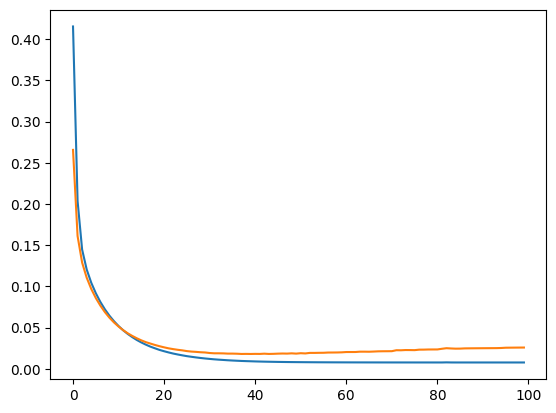

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

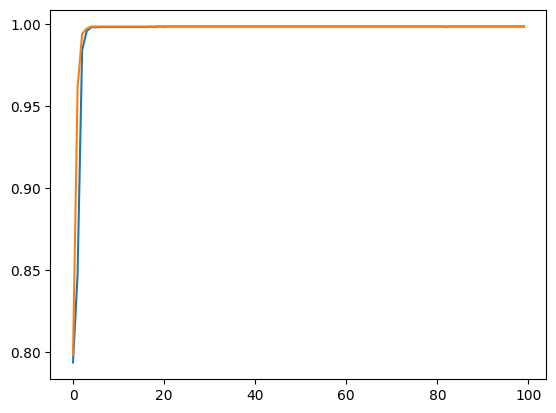

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])